### Discrete Divergence Formulation for Horizontal Force Balance

In this section, we compute the **horizontal force balance** within a 2-D Stokes model using the **discrete divergence form** of the momentum equation:

\begin{equation}
\frac{\partial \sigma_{xx}}{\partial x} + \frac{\partial \sigma_{zx}}{\partial z} = 0
\end{equation}

#### Stress mapping and grid structure
The model uses a **staggered finite-difference grid**:
- **Normal stresses** (σₓₓ) and **pressure** are defined at **cell centers**.
- **Shear stresses** (σₓ𝓏) are defined at **cell vertices**.
- The grid spacing is uniform in both x and z.

For the discrete divergence approach, we first **map all stress components to cell-face centers**:
- σxx → vertical faces (x-faces)
- σzz → horizontal faces (z-faces)

This mapping ensures that each stress component acts naturally on the boundaries of the control volume (cell), consistent with the finite-volume interpretation of equilibrium.

#### Discrete divergence and residual closure
We then compute the **discrete divergence** of the stress tensor over each cell:
\begin{equation}
R_{ij} = \frac{\sigma_{xx}(x_{j+1/2}) - \sigma_{xx}(x_{j-1/2})}{\Delta x}
       + \frac{\sigma_{zx}(z_{i+1/2}) - \sigma_{zx}(z_{i-1/2})}{\Delta z}
\end{equation}

Integrating this residual with depth gives the **cumulative horizontal force imbalance** (in Pa·m or TN/m) for each column.



In [1]:
#import pyvista as pv
import numpy as np
import glob
import natsort
import matplotlib.pyplot as plt
import h5py
from scipy.integrate import trapz, cumtrapz
from scipy.ndimage import gaussian_filter

plt.rcParams.update({
    "mathtext.fontset": "cm",  
    "font.family": "serif",     
})

from scripts.helpers import *

In [2]:
data_dir = '../model_output_data/MD7_R0/'

In [3]:
# ---------------------------------------------------------------------
# PHYSICAL CONSTANTS AND DOMAIN SETUP
# ---------------------------------------------------------------------
delrho     = 3250
g          = 9.81
s2my       = 3.1436e13
xmin       = -1600e3
xmax       = 1600e3
#swap the z coordinate to z positive down
zmin       = -20e3
zmax       = 660e3
#integration depth limit
z_c_depth  = 100e3

## Load data

In [4]:
#Load one of the HDF5 files to get some information on the grid
h5_fnames = natsort.natsorted(glob.glob(data_dir  + '*.h5')) 

# Loop through all .h5 files
for index, h5_fname in enumerate(h5_fnames):
    # Open the file using a context manager
    with h5py.File(h5_fname, 'r') as h5file:
        # Extract the time value from the file
        time = h5file["/Model/Params"][0].astype(int) / s2my
        # Print the file index and formatted time
        print(f"File index: {index}, Time step: {time:.1f} Myrs")

File index: 0, Time step: 0.0 Myrs
File index: 1, Time step: 0.2 Myrs
File index: 2, Time step: 0.6 Myrs
File index: 3, Time step: 1.0 Myrs
File index: 4, Time step: 1.4 Myrs
File index: 5, Time step: 1.8 Myrs
File index: 6, Time step: 2.2 Myrs
File index: 7, Time step: 2.6 Myrs
File index: 8, Time step: 3.0 Myrs
File index: 9, Time step: 3.4 Myrs
File index: 10, Time step: 3.8 Myrs
File index: 11, Time step: 4.3 Myrs
File index: 12, Time step: 4.7 Myrs
File index: 13, Time step: 5.1 Myrs
File index: 14, Time step: 5.6 Myrs
File index: 15, Time step: 6.0 Myrs
File index: 16, Time step: 6.5 Myrs
File index: 17, Time step: 6.9 Myrs
File index: 18, Time step: 7.4 Myrs
File index: 19, Time step: 7.8 Myrs
File index: 20, Time step: 8.2 Myrs
File index: 21, Time step: 8.6 Myrs
File index: 22, Time step: 9.0 Myrs
File index: 23, Time step: 9.4 Myrs
File index: 24, Time step: 9.7 Myrs
File index: 25, Time step: 10.1 Myrs
File index: 26, Time step: 10.5 Myrs
File index: 27, Time step: 10.9 Myrs

In [5]:
# ---------------------------------------------------------------------
# Select model snapshot and open corresponding HDF5 file
# ---------------------------------------------------------------------

# Choose which output file to analyse.
# (Negative indices count from the end; e.g. -1 = latest timestep)
file_index_number = 10

# Open the selected model output
h5file = h5py.File(h5_fnames[file_index_number], 'r')

# Access global model parameters
data = h5file['/Model/Params']

# Extract and convert model time from seconds to Myr
time = h5file['/Model/Params'][0].astype(int) / s2my

print(f" Time step: {time:.1f} Myr")

 Time step: 3.8 Myr


In [6]:

# ---------------------------------------------------------------------
# Mesh setup and geometric parameters
# ---------------------------------------------------------------------

# Nx, Nz = number of VERTICES in the x and z directions
# (each grid cell is bounded by 2 vertices ⇒ there are Nx−1 and Nz−1 cell centers)
Nx  = data[3].astype(int)
Nz  = data[4].astype(int)

# Nominal grid spacing (m)
# use ceil to avoid small floating-point rounding errors when reconstructing domain
dx  = np.ceil((xmax - xmin) / (Nx - 1))   # horizontal spacing (m)
dz  = np.ceil((zmax - zmin) / (Nz - 1))   # vertical spacing (m)

# Vertex coordinates (boundaries of cells)
vxpts = np.linspace(xmin, xmax, Nx)       # x-coordinates of vertices
vzpts = np.linspace(zmin, zmax, Nz)       # z-coordinates of vertices

# Cell-center coordinates (midpoints between adjacent vertices)
cxpts = 0.5 * (vxpts[1:] + vxpts[:-1])    # x-centers of cells  → length Nx−1
czpts = 0.5 * (vzpts[1:] + vzpts[:-1])    # z-centers of cells  → length Nz−1

# ---------------------------------------------------------------------
# Indices for reference depths / limits
# ---------------------------------------------------------------------

# Index of the vertical vertex just beyond the integration limit z_c_depth
# (used for selecting the deepest vertical integration slice)
#vbase_indx = np.argmin(np.abs(vzpts - z_c_depth))
vbase_indx = vertical_index(z_c_depth, vzpts)

# Index of the cell center nearest to z_c_depth
# (used when plotting or sampling quantities defined on cell centers)
cbase_indx = vertical_index(z_c_depth, czpts)

In [7]:
# ---------------------------------------------------------------------
# Load and prepare topography array from HDF5 file
# ---------------------------------------------------------------------

# Attempt to read "x" and "z" coordinates for surface topography.
# Some model outputs store these under 'x_mark'/'z_mark' instead of 'x'/'z'.
try:
    topo_ = np.column_stack((
        h5file["/Topo"]["x_mark"][:],
        h5file["/Topo"]["z_mark"][:]
    ))
except KeyError:
    topo_ = np.column_stack((
        h5file["/Topo"]["x"][:],
        h5file["/Topo"]["z"][:]
    ))

# Initialise a 3-column array for convenience.
# Columns: [x, z, (reserved placeholder for later derived quantity)]
new_array = np.zeros((topo_.shape[0], 3))
new_array[:, :2] = topo_

# Sort rows by x-coordinate to ensure monotonic topography profile
topo = new_array[np.argsort(new_array[:, 0])]


# ---------------------------------------------------------------------
# Identify trench position and reference index
# ---------------------------------------------------------------------

# The trench is defined as the x-position of the topographic minimum
x_trench = topo[:, 0][np.argmin(topo[:, 1])]

# Find the first mesh vertex located to the right of the trench
tindx = np.argmax(cxpts > x_trench)



In [8]:
# ---------------------------------------------------------------------
# Load and orient stress components from HDF5, assuming z is positive downward
# ---------------------------------------------------------------------

# Shear stress τ_zx (traction in x on face normal to z)
# Stored at vertices → flip vertically to ensure z increases downward
tau_zx_grid = -1 * np.flipud(h5file["/Vertices"]["sxz"][:].reshape(Nz, Nx))

# Pressure P (cell-centered) → flip vertically to match same orientation
pressure_grid = np.flipud(h5file["/Centers"]["P"][:].reshape(Nz-1, Nx-1))

# Mean (isotropic) stress: σ_I = −P
sigma_I_grid = -1 * pressure_grid                         # (Nz-1, Nx-1)

# Deviatoric normal stresses τ_xx and τ_zz = −τ_xx (plane strain assumption)
tau_xx_grid = np.flipud(h5file["/Centers"]["sxxd"][:].reshape(Nz-1, Nx-1))
tau_zz_grid = -1 * tau_xx_grid

# ---------------------------------------------------------------------
# Reconstruct total normal stresses at cell centers
# ---------------------------------------------------------------------

# Total σ_xx = σ_I + τ_xx
sig_xx_grid = sigma_I_grid + tau_xx_grid

# ---------------------------------------------------------------------
# load temperatrue grid
# ---------------------------------------------------------------------
temp_grid = np.flipud(h5file["/Centers"]['T'][:].reshape(Nz-1, Nx-1))

## Calculate the cumulative horizontal force residual for a column of cells

In [9]:

myindx =  horizontal_index(x_trench + 200e3, vxpts)


#This function computes the discrete vertical cumulative residual of the horizontal force balance for a single column 
#i in the stress grid, using a finite-volume (divergence form) approach.
#It first maps the normal stress \sigma_{xx} to vertical faces and computes its horizontal derivative 
#\partial_x \sigma_{xx} across the column.
#Then it computes the vertical derivative \partial_z \tau_{zx} of the shear stress evaluated at horizontal faces.
#The sum of these two terms gives the discrete divergence of stress 
#Finally, this residual is vertically integrated from the surface downward, 
#giving the cumulative imbalance \int (\partial_x \sigma_{xx} + \partial_z \tau_{zx}) \, dz as a function of depth.

zcuts, Rdiv_cum = residual_divergence_column(myindx, sig_xx_grid, tau_zx_grid, vzpts, dx, dz)

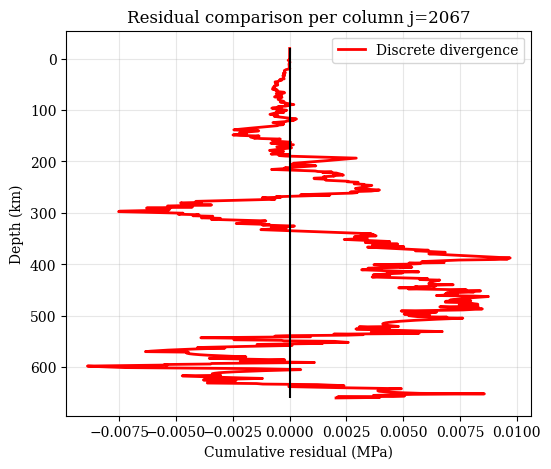

In [10]:

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(Rdiv_cum/1e6, czpts/1e3, 'r-', lw=2, label='Discrete divergence')
ax.invert_yaxis()
ax.set_xlabel('Cumulative residual (MPa)')
ax.set_ylabel('Depth (km)')
ax.set_title(f'Residual comparison per column j={myindx}')
ax.legend()
ax.grid(True, alpha=0.3)
ax.vlines(0, -20, 660, color='k')
plt.show()

#print("max |Δ| =", np.max(np.abs(Rdiv_cum - Rtrac_cum)))

In [11]:
#This function computes the discrete divergence of stress over the entire 2-D domain using a vectorized (grid-wide) 
#finite-volume formulation.
#It produces the same result as running residual_divergence_column for every column, 
#but does so efficiently across the whole grid.

zcuts, R_cum_div_grid = residual_divergence_grid(sig_xx_grid, tau_zx_grid, vzpts, dx, dz)


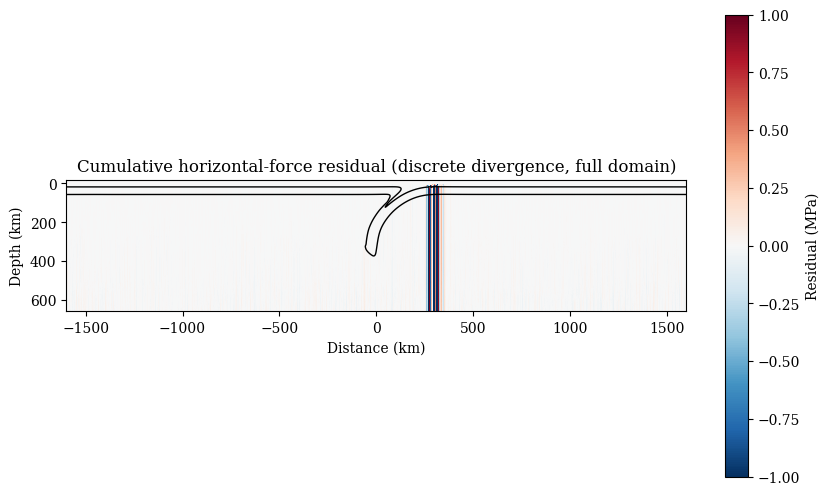

In [12]:
# x,z coordinates in km
cx = 0.5 * (vxpts[1:] + vxpts[:-1])
x_km = cx / 1e3
z_km = zcuts / 1e3

# --- plot full domain cumulative residuals (MPa) ---
fig, ax = plt.subplots(figsize=(10,6))
im = ax.pcolormesh(x_km, z_km, (R_cum_div_grid)/1e6, cmap='RdBu_r',vmin =-1, vmax=1, shading='auto')
# Convert contour levels to Kelvin
contour_levels_C = [600,1300]
contours = ax.contour(1e-3*cxpts, 1e-3*czpts, temp_grid, levels=contour_levels_C, colors='k', linewidths=1)


ax.invert_yaxis()
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Depth (km)')
ax.set_title('Cumulative horizontal-force residual (discrete divergence, full domain)')
fig.colorbar(im, ax=ax, label='Residual (MPa)')
ax.set_aspect(1)

plt.show()

## Now compute the horizontal integral - effectively the net force due to the residual

In [13]:

horizontal_cumulative_residual = np.cumsum(R_cum_div_grid* dx, axis=1)

## And plot as a function of depth

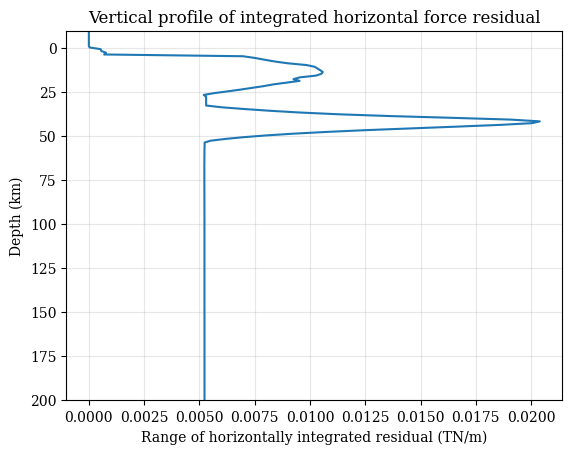

In [14]:
fig, ax = plt.subplots()

ax.plot(1e-12*(np.max(horizontal_cumulative_residual, axis = 1) - np.min(horizontal_cumulative_residual, axis = 1)),
        1e-3*czpts)

ax.set_ylim(200, -10)

# --- Axis labels and title ---
ax.set_xlabel("Range of horizontally integrated residual (TN/m)")
ax.set_ylabel("Depth (km)")
ax.set_title("Vertical profile of integrated horizontal force residual")

# --- Grid and styling (optional) ---
ax.grid(True, alpha=0.3)

## Plot  mesh mappings

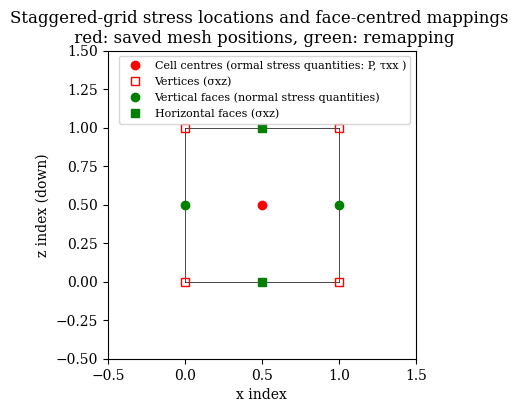

In [15]:
# Simple 4×3 mesh (3 cells wide, 2 cells tall)
# Simple 4×3 mesh (3 cells wide, 2 cells tall)
Nx, Nz = 2, 2
vx = np.arange(Nx)              # vertex x positions
vz = np.arange(Nz)              # vertex z positions
cx = 0.5*(vx[:-1] + vx[1:])     # cell-center x
cz = 0.5*(vz[:-1] + vz[1:])     # cell-center z

fig, ax = plt.subplots(figsize=(6,4))

# Plot cell boundaries
for x in vx:
    ax.plot([x, x], [vz[0], vz[-1]], 'k-', lw=0.5)
for z in vz:
    ax.plot([vx[0], vx[-1]], [z, z], 'k-', lw=0.5)

# Plot cell centers (pressure, σxx, σzz)
for x in cx:
    for z in cz:
        ax.plot(x, z, 'ro', label='Cell centres (ormal stress quantities: P, τxx )' if (x==cx[0] and z==cz[0]) else "")

# Plot vertices (σxz)
for x in vx:
    for z in vz:
        ax.plot(x, z, 'rs', mfc='none', label='Vertices (σxz)' if (x==vx[0] and z==vz[0]) else "")

# Plot vertical faces (σxx)
for x in vx:
    for z in cz:
        ax.plot(x, z, 'go', label='Vertical faces (normal stress quantities)' if (x==vx[0] and z==cz[0]) else "")

# Plot horizontal faces (σxz)
for x in cx:
    for z in vz:
        ax.plot(x, z, 'gs', label='Horizontal faces (σxz)' if (x==cx[0] and z==vz[0]) else "")

ax.set_xlim(-0.5, Nx-0.5)
ax.set_ylim(-0.5, Nz-0.5)
ax.set_aspect('equal')
ax.set_xlabel('x index')
ax.set_ylabel('z index (down)')
ax.set_title('Staggered-grid stress locations and face-centred mappings \n red: saved mesh positions, green: remapping')
ax.legend(loc='upper right', fontsize=8)
plt.show()